> **Scope note.** This notebook is the exploratory analysis over the **full labelled corpus** (1,110,153 Reddit and 378,267 YouTube comments).
>
> The figures reported in the paper come from **`06_revision/`**, which restricts both platforms to the matched 7 October 2023 to 7 May 2024 window and removes automated accounts, leaving 1,004,629 Reddit comments. Where the two differ, `06_revision/` is authoritative.

# RQ4: Toxic Discourse (Perspective API)

**Research Question 4 - Which platform / stance harbors the most toxic speech?**

This module scores comments with Google's **Perspective API** across six attributes
- TOXICITY, SEVERE_TOXICITY, IDENTITY_ATTACK, INSULT, THREAT, PROFANITY - and
compares toxicity across platforms and stances.

The Perspective API is rate-limited (~60 requests/minute on the free tier), so the
analysis runs on a **stratified sample** per platform. Increase `SAMPLE_SIZE` for a
larger run.

**Setup:** add your key to a `.env` file in the repo root:
```
PERSPECTIVE_API_KEY=your_key_here
```
Get one at https://developers.perspectiveapi.com/s/docs-get-started

**Stance labels:** `P` = Pro-Palestine, `I` = Pro-Israel, `N` = Neutral.

## 1. Setup and API Client

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from dotenv import load_dotenv
from googleapiclient import discovery

load_dotenv()

STANCE_ORDER = ["P", "I", "N"]
STANCE_NAMES = {"P": "Pro-Palestine", "I": "Pro-Israel", "N": "Neutral"}
ATTRIBUTES = ["TOXICITY", "SEVERE_TOXICITY", "IDENTITY_ATTACK", "INSULT", "THREAT", "PROFANITY"]


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "reddit_labeled.csv").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "05_toxicity_analysis" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

API_KEY = os.getenv("PERSPECTIVE_API_KEY")
PERSPECTIVE_ENABLED = bool(API_KEY)
if PERSPECTIVE_ENABLED:
    client = discovery.build(
        "commentanalyzer", "v1alpha1", developerKey=API_KEY,
        discoveryServiceUrl="https://commentanalyzer.googleapis.com/$discovery/rest?version=v1alpha1",
        static_discovery=False,
    )
    print("Perspective API client ready.")
else:
    client = None
    print("PERSPECTIVE_API_KEY not found.")
    print("Add it to a .env file in the repo root to run the live toxicity analysis:")
    print("  PERSPECTIVE_API_KEY=your_key_here")


def get_perspective_scores(text):
    if not isinstance(text, str) or len(text) < 2:
        return None
    request = {
        "comment": {"text": text[:3000]},
        "requestedAttributes": {a: {} for a in ATTRIBUTES},
        "languages": ["en"],
    }
    try:
        resp = client.comments().analyze(body=request).execute()
        return {a: resp["attributeScores"][a]["summaryScore"]["value"]
                for a in resp["attributeScores"]}
    except Exception:
        return None


print(f"Output dir: {OUTPUT_DIR}")

c:\Users\nitro 5\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Perspective API client ready.
Output dir: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\05_toxicity_analysis\outputs


## 2. Load Data and Draw a Stratified Sample

In [2]:
reddit_df = pd.read_csv(DATA_DIR / "reddit_labeled.csv")
youtube_df = pd.read_csv(DATA_DIR / "youtube_labeled.csv")
reddit_df = reddit_df[reddit_df["Label"].isin(STANCE_ORDER)].copy()
youtube_df = youtube_df[youtube_df["Label"].isin(STANCE_ORDER)].copy()

# Total comments to score per platform (API quota friendly). Increase for a fuller run.
SAMPLE_SIZE = 300
per_stance = SAMPLE_SIZE // len(STANCE_ORDER)


def stratified_sample(df):
    return df.groupby("Label", group_keys=False).apply(
        lambda g: g.sample(min(len(g), per_stance), random_state=42))


r_sample = stratified_sample(reddit_df)
y_sample = stratified_sample(youtube_df)
print(f"Reddit sample : {len(r_sample)} ({per_stance}/stance)")
print(f"YouTube sample: {len(y_sample)} ({per_stance}/stance)")

Reddit sample : 300 (100/stance)
YouTube sample: 300 (100/stance)


## 3. Run Perspective API

Each comment is one API call with a short pause to respect the rate limit, so this
cell takes a few minutes. Requires `PERSPECTIVE_API_KEY`.

In [3]:
if not PERSPECTIVE_ENABLED:
    raise RuntimeError("Add PERSPECTIVE_API_KEY to .env and re-run from this cell.")


def process_batch(df, text_col, sleep=1.1):
    rows = []
    for text in tqdm(df[text_col].tolist(), desc=text_col):
        scores = get_perspective_scores(str(text))
        rows.append(scores if scores else {a: np.nan for a in ATTRIBUTES})
        if scores:
            time.sleep(sleep)  # respect ~60 req/min free tier
    return pd.DataFrame(rows, index=df.index)


print("Scoring Reddit sample...")
r_final = r_sample.join(process_batch(r_sample, "self_text"))
print("Scoring YouTube sample...")
y_final = y_sample.join(process_batch(y_sample, "text"))

# Persist raw scored samples immediately so the API work is not lost
r_final.to_csv(OUTPUT_DIR / "reddit_perspective.csv", index=False)
y_final.to_csv(OUTPUT_DIR / "youtube_perspective.csv", index=False)
print(f"Scored {r_final['TOXICITY'].notna().sum()} Reddit and "
      f"{y_final['TOXICITY'].notna().sum()} YouTube comments.")

Scoring Reddit sample...


self_text: 100%|██████████| 300/300 [07:21<00:00,  1.47s/it]


Scoring YouTube sample...


text: 100%|██████████| 300/300 [07:11<00:00,  1.44s/it]

Scored 299 Reddit and 296 YouTube comments.


## 4. Toxicity Visualizations

Mean attribute scores by platform:
                 Reddit  YouTube
TOXICITY         0.2371   0.1592
IDENTITY_ATTACK  0.1681   0.0823
INSULT           0.1314   0.0965
THREAT           0.0821   0.0436


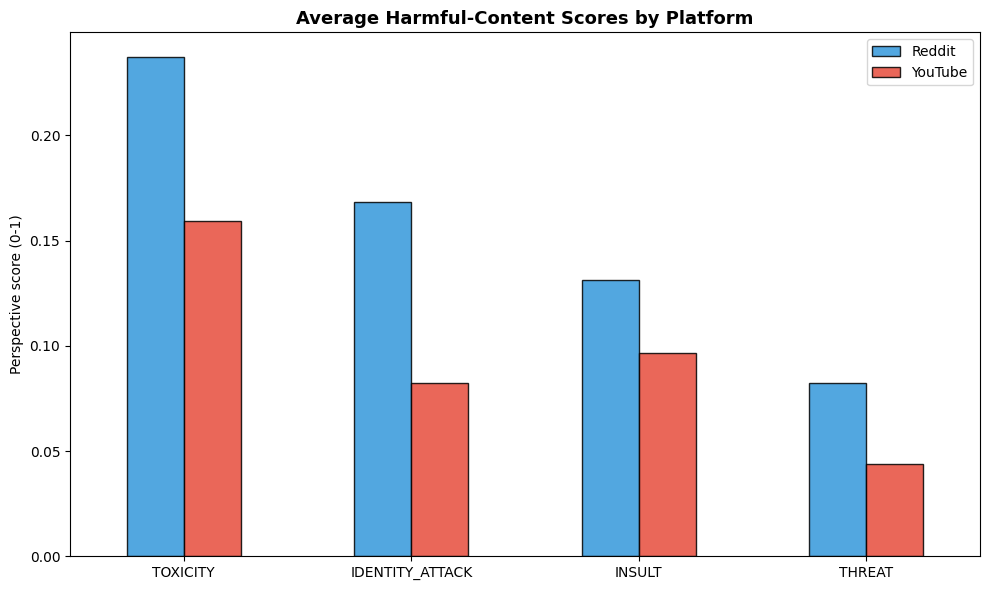

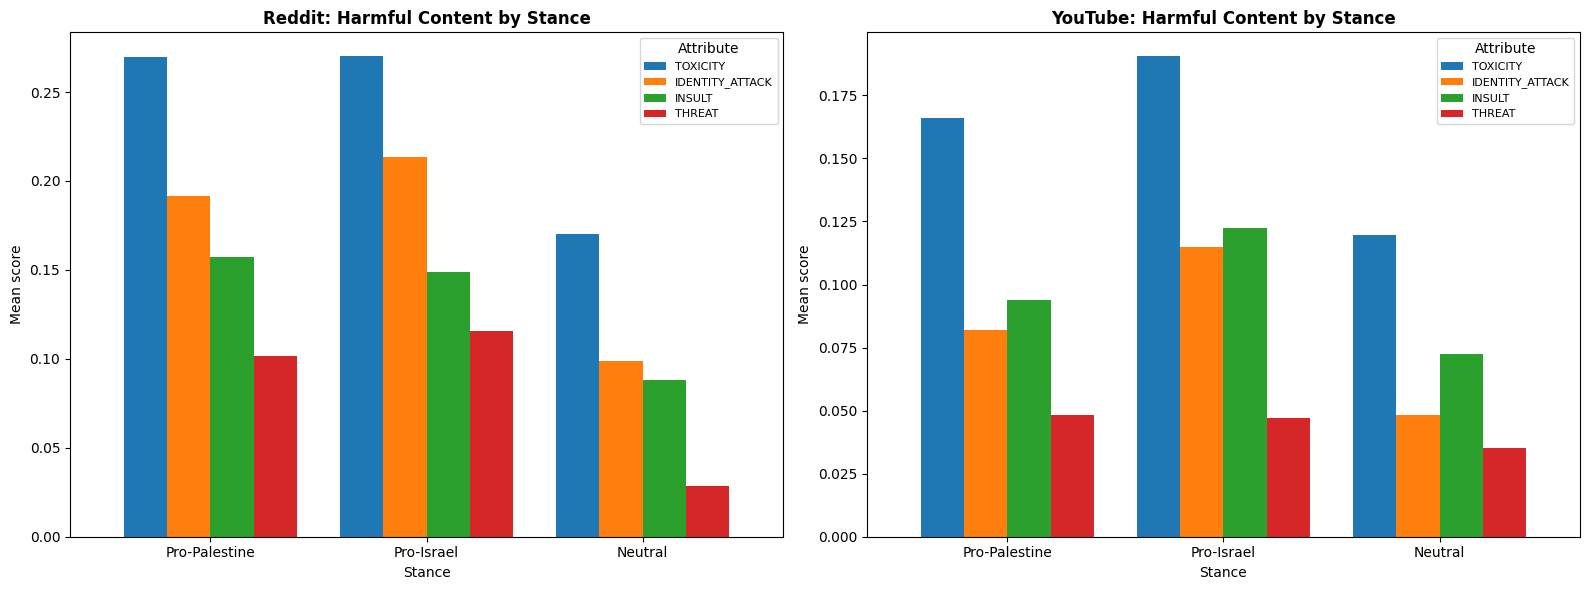

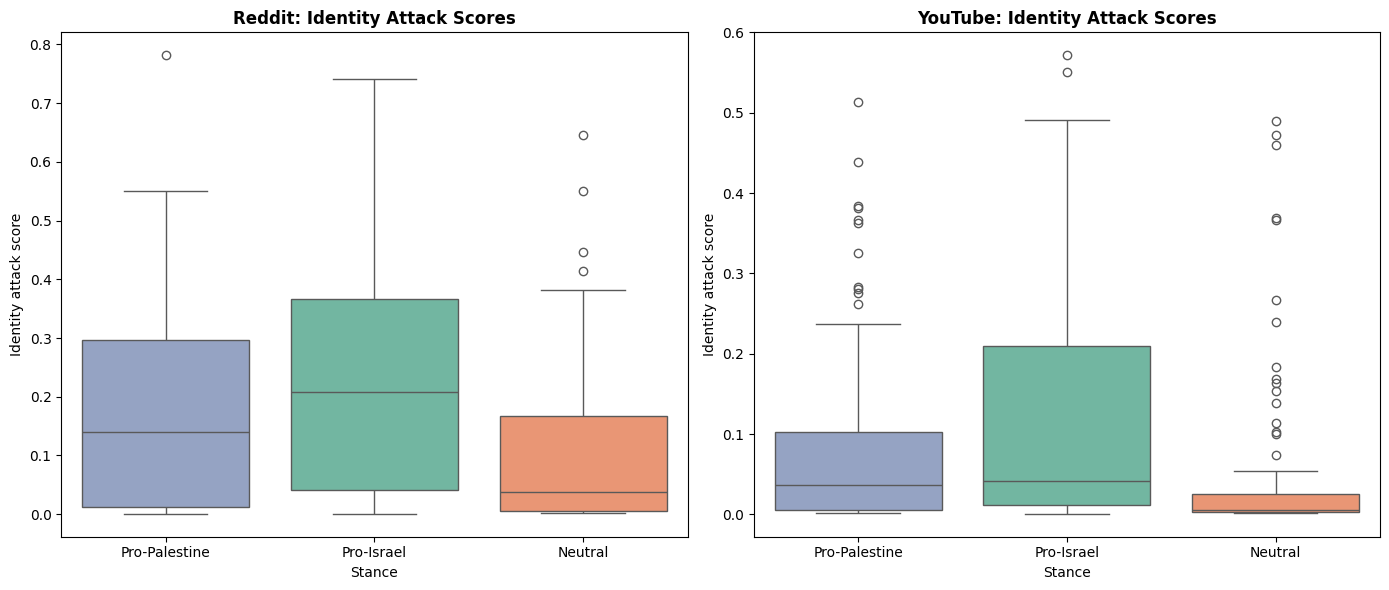

In [13]:
def ensure_stance(df, source_csv_path):
    for col in ["Label", "label", "stance", "Stance"]:
        if col in df.columns:
            mapped = df[col].map(STANCE_NAMES)
            df["stance"] = mapped.fillna(df[col])
            return df

    # If scored files were loaded without labels, recover stance from source CSV via index.
    if "index" in df.columns:
        lookup = (
            pd.read_csv(source_csv_path, usecols=["index", "Label"])
.drop_duplicates(subset=["index"])
.set_index("index")["Label"]
        )
        recovered = df["index"].map(lookup).map(STANCE_NAMES)
        if recovered.notna().any():
            df["stance"] = recovered
            return df

    raise KeyError(
        "No stance label column found and recovery failed. Re-run Cells 2 and 3 to rebuild samples with labels."
    )


r_final = ensure_stance(r_final.copy(), DATA_DIR / "reddit_labeled.csv")
y_final = ensure_stance(y_final.copy(), DATA_DIR / "youtube_labeled.csv")
key_attrs = ["TOXICITY", "IDENTITY_ATTACK", "INSULT", "THREAT"]

# 4.1 Platform comparison
comparison = pd.DataFrame({"Reddit": r_final[key_attrs].mean(),
                           "YouTube": y_final[key_attrs].mean()})
print("Mean attribute scores by platform:")
print(comparison.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"], alpha=0.85, edgecolor="black")
ax.set_title("Average Harmful-Content Scores by Platform", fontsize=13, fontweight="bold")
ax.set_ylabel("Perspective score (0-1)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4.2 By stance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in [(axes[0], r_final, "Reddit"), (axes[1], y_final, "YouTube")]:
    means = df.groupby("stance")[key_attrs].mean().reindex(
        [STANCE_NAMES[s] for s in STANCE_ORDER])
    means.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(f"{title}: Harmful Content by Stance", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean score"); ax.set_xlabel("Stance")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    ax.legend(title="Attribute", fontsize=8)
plt.tight_layout()
plt.show()

# 4.3 Identity-attack distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, title in [(axes[0], r_final, "Reddit"), (axes[1], y_final, "YouTube")]:
    sns.boxplot(data=df, x="stance", y="IDENTITY_ATTACK",
                order=[STANCE_NAMES[s] for s in STANCE_ORDER],
                hue="stance", legend=False, palette="Set2", ax=ax)
    ax.set_title(f"{title}: Identity Attack Scores", fontsize=12, fontweight="bold")
    ax.set_ylabel("Identity attack score"); ax.set_xlabel("Stance")
plt.tight_layout()
plt.show()

## 5. Statistical Significance Tests

In [15]:
def to_stance_code(series):
    inv = {v: k for k, v in STANCE_NAMES.items()}
    return series.map(lambda x: inv.get(x, x))


def get_stance_codes(df):
    for col in ["Label", "label", "Stance", "stance"]:
        if col in df.columns:
            return to_stance_code(df[col])
    raise KeyError("No stance column found for statistical tests.")


print("Mann-Whitney U (Reddit vs YouTube):")
for attr in ATTRIBUTES:
    a, b = r_final[attr].dropna(), y_final[attr].dropna()
    if len(a) and len(b):
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  {attr:16s}: U={u:.0f}, p={p:.4f} {'*' if p < 0.05 else ''}")

print("\nKruskal-Wallis (stance differences):")
for name, df in [("Reddit", r_final), ("YouTube", y_final)]:
    stance_codes = get_stance_codes(df)
    for attr in key_attrs:
        groups = [df.loc[stance_codes == s, attr].dropna() for s in STANCE_ORDER]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            h, p = stats.kruskal(*groups)
            print(f"  {name} - {attr:16s}: H={h:.2f}, p={p:.4f} {'*' if p < 0.05 else ''}")

Mann-Whitney U (Reddit vs YouTube):
  TOXICITY        : U=54456, p=0.0000 *
  SEVERE_TOXICITY : U=53244, p=0.0000 *
  IDENTITY_ATTACK : U=57520, p=0.0000 *
  INSULT          : U=53201, p=0.0000 *
  THREAT          : U=53274, p=0.0000 *
  PROFANITY       : U=52858, p=0.0000 *

Kruskal-Wallis (stance differences):
  Reddit - TOXICITY        : H=22.79, p=0.0000 *
  Reddit - IDENTITY_ATTACK : H=26.24, p=0.0000 *
  Reddit - INSULT          : H=23.03, p=0.0000 *
  Reddit - THREAT          : H=45.09, p=0.0000 *
  YouTube - TOXICITY        : H=14.23, p=0.0008 *
  YouTube - IDENTITY_ATTACK : H=30.42, p=0.0000 *
  YouTube - INSULT          : H=9.79, p=0.0075 *
  YouTube - THREAT          : H=15.07, p=0.0005 *


### Effect Sizes

Standardized effect sizes alongside the tests above: **rank-biserial correlation** for
the platform Mann-Whitney contrasts and **epsilon-squared** for the stance
Kruskal-Wallis tests.

In [16]:
def rank_biserial(u, n1, n2):
    return 1 - (2.0 * u) / (n1 * n2)


def epsilon_squared(h, n):
    return h / (n - 1)


def to_stance_code(series):
    inv = {v: k for k, v in STANCE_NAMES.items()}
    return series.map(lambda x: inv.get(x, x))


def get_stance_codes(df):
    for col in ["Label", "label", "Stance", "stance"]:
        if col in df.columns:
            return to_stance_code(df[col])
    raise KeyError("No stance column found for effect-size tests.")


print("Platform contrast (rank-biserial r):")
for attr in ATTRIBUTES:
    a, b = r_final[attr].dropna(), y_final[attr].dropna()
    if len(a) and len(b):
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  {attr:16s}: r={rank_biserial(u, len(a), len(b)):+.3f}")

print("\nStance effect (epsilon^2):")
for name, df in [("Reddit", r_final), ("YouTube", y_final)]:
    stance_codes = get_stance_codes(df)
    for attr in key_attrs:
        groups = [df.loc[stance_codes == s, attr].dropna() for s in STANCE_ORDER]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            h, p = stats.kruskal(*groups)
            n = sum(len(g) for g in groups)
            print(f"  {name} {attr:16s}: epsilon^2={epsilon_squared(h, n):.3f}")

Platform contrast (rank-biserial r):
  TOXICITY        : r=-0.231
  SEVERE_TOXICITY : r=-0.203
  IDENTITY_ATTACK : r=-0.300
  INSULT          : r=-0.202
  THREAT          : r=-0.204
  PROFANITY       : r=-0.194

Stance effect (epsilon^2):
  Reddit TOXICITY        : epsilon^2=0.076
  Reddit IDENTITY_ATTACK : epsilon^2=0.088
  Reddit INSULT          : epsilon^2=0.077
  Reddit THREAT          : epsilon^2=0.151
  YouTube TOXICITY        : epsilon^2=0.048
  YouTube IDENTITY_ATTACK : epsilon^2=0.103
  YouTube INSULT          : epsilon^2=0.033
  YouTube THREAT          : epsilon^2=0.051


## Summary - RQ4 Findings

- **Platform** - the platform comparison and Mann-Whitney tests show whether
  Reddit or YouTube carries more toxic / harmful content across the six attributes.
- **Stance** - by-stance means and Kruskal-Wallis tests reveal which stances are
  associated with higher toxicity and identity attacks.
- **Reproducibility** - scored samples are saved to `outputs/` so the (rate-limited)
  API work is preserved and can be re-analysed without re-querying.

Scale up by raising `SAMPLE_SIZE`; the stratified design keeps all three stances
represented.